# Stage 3: SIFT Enhancement

Demonstrates SIFT feature detection and matching for enhanced tracking:
1. SIFT keypoint detection
2. Feature description  
3. Feature matching between frames
4. Detection validation using SIFT
5. Comparison with standard pipeline


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
sys.path.append('..')

from sot import SIFTFeatureStep, SIFTMatchingStep, SIFTEnhancedDetectionStep
from detector import ObjectDetector

plt.rcParams['figure.figsize'] = (15, 10)


## SIFT Keypoint Detection

Detect scale-invariant features in bee images.


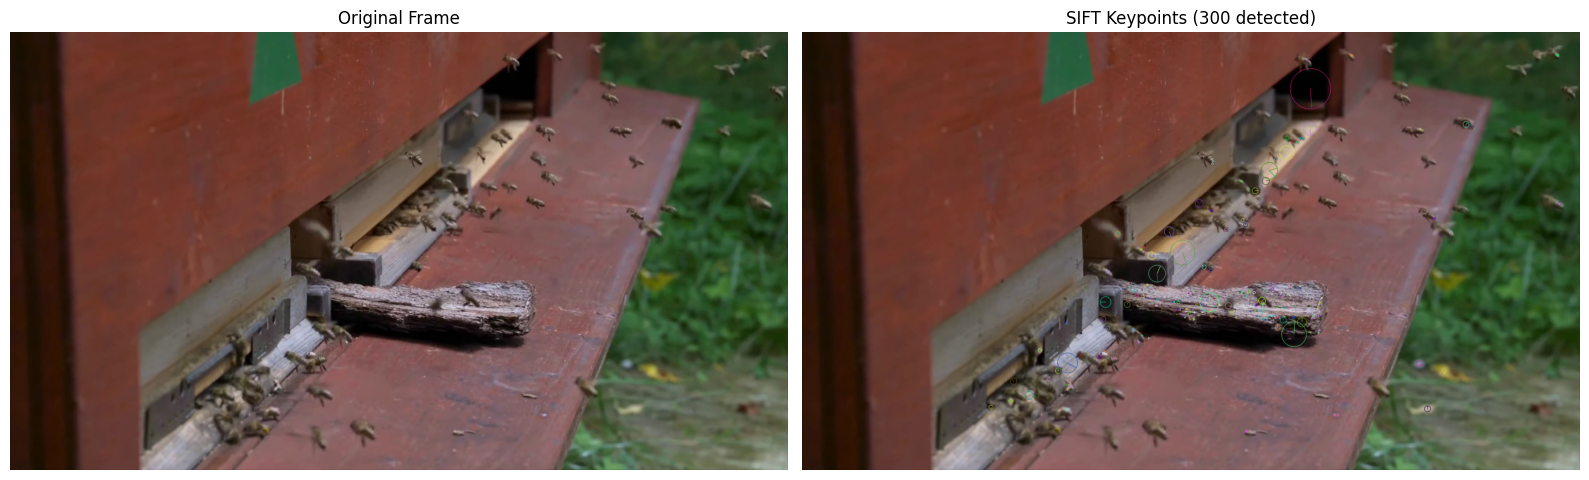

Detected 300 SIFT keypoints
Descriptor shape: (300, 128) (128-dimensional vectors)


In [15]:
frame_files = sorted(glob.glob("../data/images/bees_short/images/*.jpg"))[:50]
frames = [cv2.imread(f) for f in frame_files]

sift = cv2.SIFT_create(nfeatures=300, contrastThreshold=0.04, edgeThreshold=10)

frame = frames[20]
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
keypoints, descriptors = sift.detectAndCompute(gray, None)

vis = cv2.drawKeypoints(frame, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Frame')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'SIFT Keypoints ({len(keypoints)} detected)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Detected {len(keypoints)} SIFT keypoints")
print(f"Descriptor shape: {descriptors.shape} (128-dimensional vectors)")


## Feature Matching

Match SIFT features between consecutive frames.


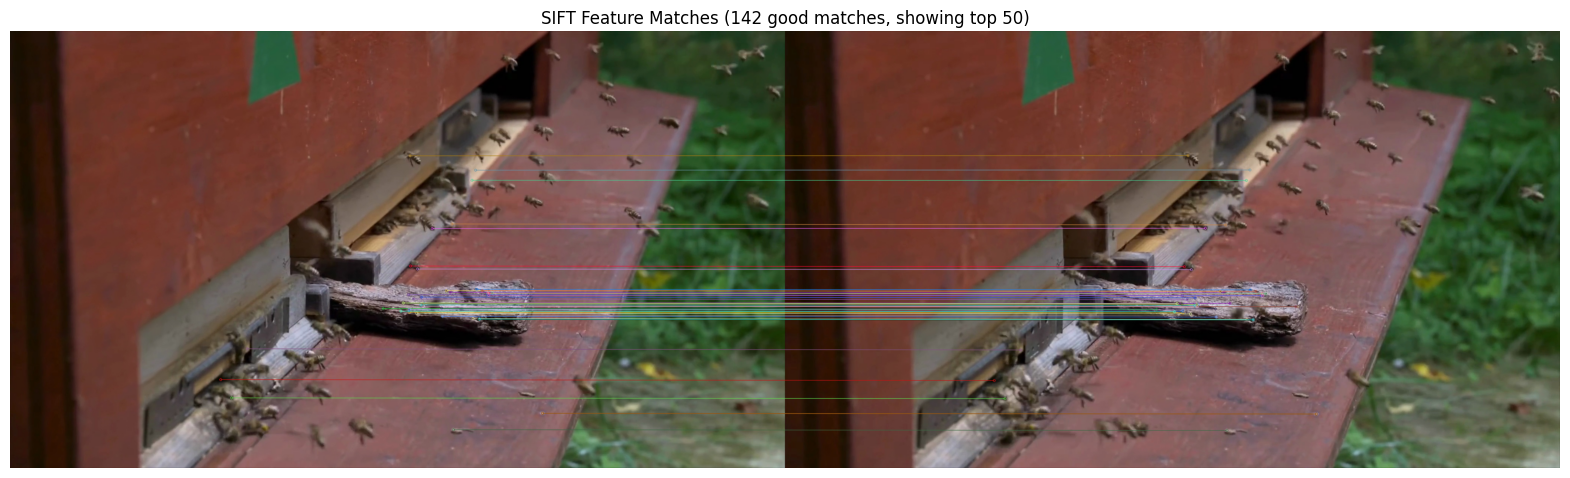

Total matches: 300
Good matches (Lowe's ratio test): 142
Match ratio: 47.3%


In [16]:
frame1 = frames[20]
frame2 = frames[21]

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
ratio_threshold = 0.75
for match_pair in matches:
    if len(match_pair) == 2:
        m, n = match_pair
        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)

vis_matches = cv2.drawMatches(frame1, kp1, frame2, kp2, good_matches[:50], None,
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(vis_matches, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Feature Matches ({len(good_matches)} good matches, showing top 50)')
plt.axis('off')
plt.show()

print(f"Total matches: {len(matches)}")
print(f"Good matches (Lowe's ratio test): {len(good_matches)}")
print(f"Match ratio: {len(good_matches)/len(matches)*100:.1f}%")


## Detection Validation with SIFT

Compare standard vs SIFT-enhanced detection.


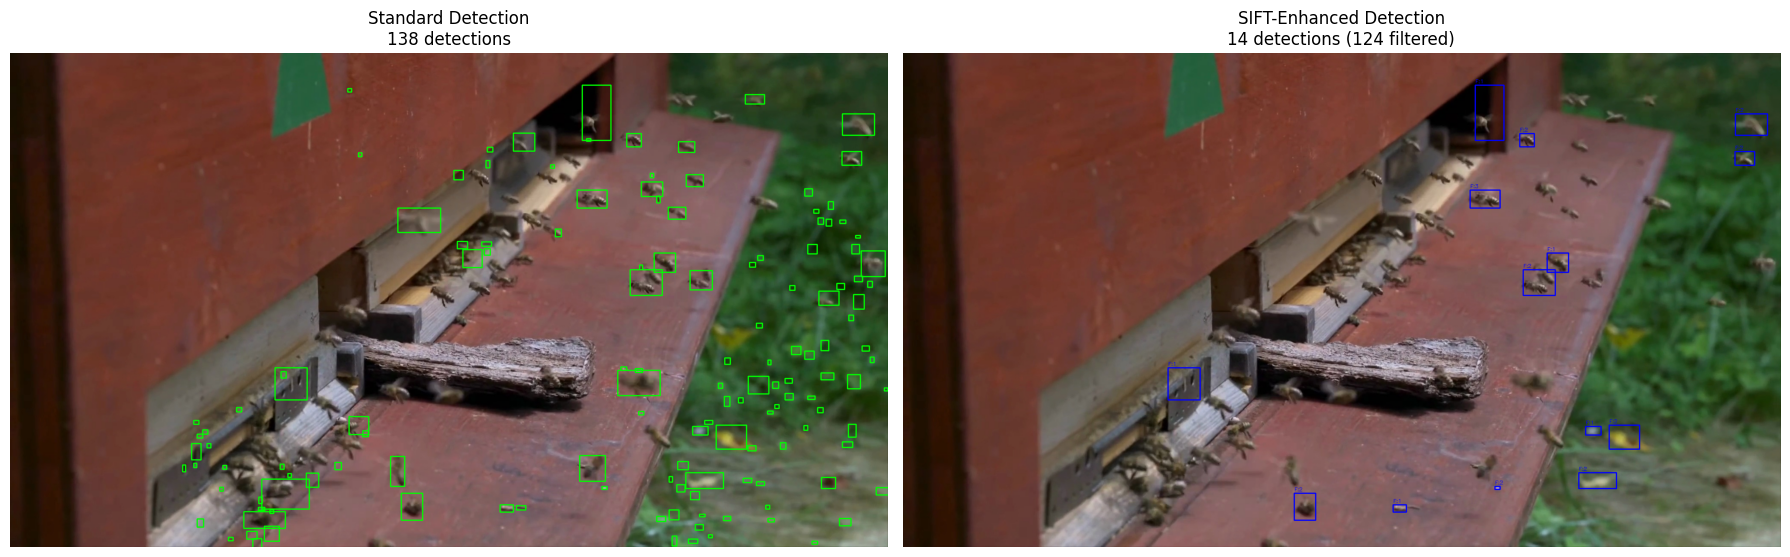

Standard detections: 138
SIFT-enhanced detections: 14
Filtered out: 124 (89.9%)


In [17]:
detector_std = ObjectDetector(history=500, dist_threshold=1000, min_area=30, max_area=100000)
detector_sift = ObjectDetector(history=500, dist_threshold=1000, min_area=30, max_area=100000)

# Learn background
for f in frames[:30]:
    detector_std.detect(f)
    detector_sift.detect(f)

test_frame = frames[33]

dets_std = detector_std.detect(test_frame)

gray = cv2.cvtColor(test_frame, cv2.COLOR_BGR2GRAY)
keypoints, descriptors = sift.detectAndCompute(gray, None)

dets_sift_filtered = []
feature_counts = []

for det in dets_std:
    cx, cy, w, h = det
    x1, y1 = int(cx - w/2), int(cy - h/2)
    x2, y2 = int(cx + w/2), int(cy + h/2)
    
    features_in_bbox = 0
    for kp in keypoints:
        kp_x, kp_y = kp.pt
        if x1 <= kp_x <= x2 and y1 <= kp_y <= y2:
            features_in_bbox += 1
    
    bbox_area = w * h
    feature_density = features_in_bbox / bbox_area if bbox_area > 0 else 0
    
    if features_in_bbox >= 1 or feature_density >= 0.01:
        dets_sift_filtered.append(det)
        feature_counts.append(features_in_bbox)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Standard
vis_std = test_frame.copy()
for det in dets_std:
    cx, cy, w, h = det
    x, y = int(cx - w/2), int(cy - h/2)
    cv2.rectangle(vis_std, (x, y), (x+w, y+h), (0, 255, 0), 2)

axes[0].imshow(cv2.cvtColor(vis_std, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Standard Detection\n{len(dets_std)} detections')
axes[0].axis('off')

# SIFT-enhanced
vis_sift = test_frame.copy()
for i, det in enumerate(dets_sift_filtered):
    cx, cy, w, h = det
    x, y = int(cx - w/2), int(cy - h/2)
    cv2.rectangle(vis_sift, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(vis_sift, f"F:{feature_counts[i]}", (x, y-5),
               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

axes[1].imshow(cv2.cvtColor(vis_sift, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'SIFT-Enhanced Detection\n{len(dets_sift_filtered)} detections ({len(dets_std)-len(dets_sift_filtered)} filtered)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Standard detections: {len(dets_std)}")
print(f"SIFT-enhanced detections: {len(dets_sift_filtered)}")
print(f"Filtered out: {len(dets_std) - len(dets_sift_filtered)} ({(1-len(dets_sift_filtered)/max(len(dets_std),1))*100:.1f}%)")
